# Predictive Modeling Using Machine Learning

**Goal:** Build a model to predict outcomes based on given data.

This notebook covers:
1. Load & clean raw customer data
2. Preprocess features (encoding, scaling)
3. Train Logistic Regression, Decision Tree, and Random Forest
4. Evaluate with accuracy, precision, recall, F1, ROC AUC
5. Visualize performance with confusion matrices and ROC curves
6. Compare models and identify key predictive features


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, auc, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load Raw Data

In [2]:
df = pd.read_csv("../data/raw_customer_data.csv")
print(df.shape)
df.head()

(1515, 13)


,CustomerID,SeniorCitizen,TenureMonths,ContractType,InternetService,TechSupport,OnlineSecurity,PaperlessBilling,PaymentMethod,NumSupportCalls,MonthlyCharges,TotalCharges,Churn
0,CUST2000,0,52,Two Year,Fiber Optic,Yes,No,Yes,Bank Transfer,3,77.06,3689.70,0
1,CUST2001,0,15,Month-to-Month,DSL,No,No,No,Electronic Check,1,54.50,803.23,0
2,CUST2002,0,61,Month-to-Month,Fiber Optic,No,No,Yes,Credit Card,1,93.28,6217.76,0
3,CUST2003,0,21,One Year,DSL,No,No,No,Mailed Check,0,58.13,1196.39,1
4,CUST2004,0,24,One Year,No Internet,No,Yes,Yes,Bank Transfer,4,99.61,2325.52,0


In [3]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate CustomerIDs:", df['CustomerID'].duplicated().sum())
print("\nChurn rate:", df['Churn'].mean().round(3))

Missing values:
 CustomerID           0
SeniorCitizen        0
TenureMonths         0
ContractType         0
InternetService      0
TechSupport          0
OnlineSecurity       0
PaperlessBilling     0
PaymentMethod        0
NumSupportCalls      0
MonthlyCharges       0
TotalCharges        25
Churn                0
dtype: int64

Duplicate CustomerIDs: 15

Churn rate: 0.222


## 2. Clean & Preprocess

- Drop duplicate `CustomerID` rows
- Impute missing `TotalCharges` with the median
- Label-encode categorical columns
- Split into train/test (80/20, stratified on target)
- Standardize features for Logistic Regression


In [4]:
df = df.drop_duplicates(subset=["CustomerID"], keep="first")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

cat_cols = ["ContractType", "InternetService", "TechSupport", "OnlineSecurity",
            "PaperlessBilling", "PaymentMethod"]
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

feature_cols = ["SeniorCitizen", "TenureMonths", "ContractType", "InternetService",
                 "TechSupport", "OnlineSecurity", "PaperlessBilling", "PaymentMethod",
                 "NumSupportCalls", "MonthlyCharges", "TotalCharges"]
X = df[feature_cols]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1200, 11) Test: (300, 11)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Train Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
}

results = {}
predictions = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.70,0.3947,0.6818,0.5000,0.7569
Decision Tree,0.66,0.3500,0.6364,0.4516,0.6628
Random Forest,0.77,0.4706,0.3636,0.4103,0.7595


## 4. Evaluate: Confusion Matrices

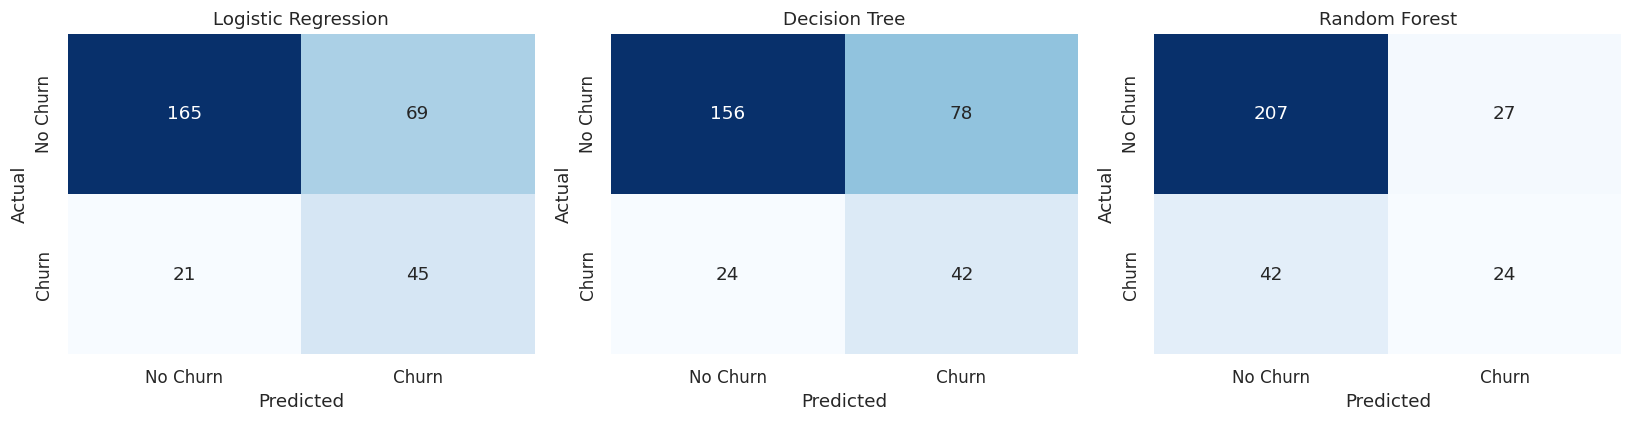

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 5. Evaluate: ROC Curves

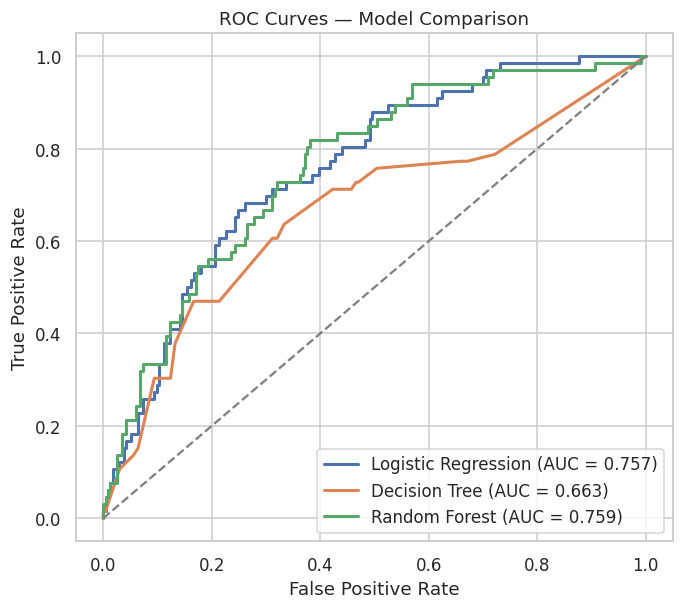

In [8]:
plt.figure(figsize=(7,6))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title("ROC Curves — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 6. Feature Importance (Random Forest)

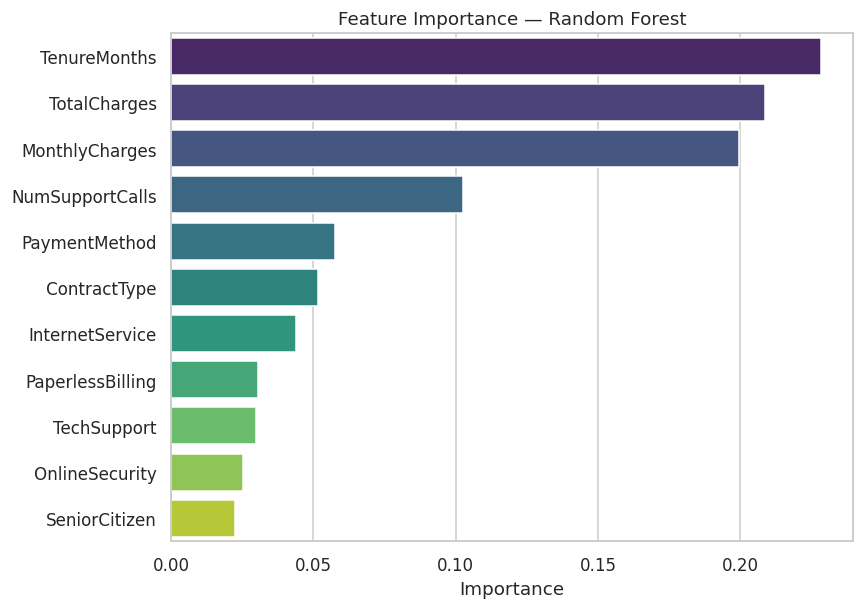

In [9]:
rf = models["Random Forest"]
imp = sorted(zip(feature_cols, rf.feature_importances_), key=lambda x: x[1], reverse=True)
names, vals = zip(*imp)

plt.figure(figsize=(8,6))
sns.barplot(x=list(vals), y=list(names), hue=list(names), palette="viridis", legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.show()

In [10]:
print(classification_report(y_test, predictions["Random Forest"]["y_pred"]))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       234
           1       0.47      0.36      0.41        66

    accuracy                           0.77       300
   macro avg       0.65      0.62      0.63       300
weighted avg       0.75      0.77      0.76       300



## 7. Key Findings

- **Random Forest and Logistic Regression** achieve the highest ROC AUC (~0.76), meaningfully outperforming the single Decision Tree (~0.66).
- **Tenure, Total Charges, and Monthly Charges** are the strongest predictors of churn — newer customers with higher charges are most likely to churn.
- Contract type and number of support calls also carry meaningful signal: month-to-month contracts and frequent support calls correlate with higher churn.
- With class imbalance (~22% churn), using `class_weight='balanced'` was essential — without it, models defaulted to predicting "no churn" and had near-zero recall on the churn class.
- **Recommendation:** Random Forest is the best overall model here (highest accuracy and ROC AUC), but if catching every at-risk customer matters more than precision, Logistic Regression's higher recall makes it a strong alternative.
